In [1]:
# Supply chain analysis of feedstock cost impact on MJSP
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, additional_rcf
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank


chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

In [2]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:

ethanol_in_beer = bst.Stream('Ethanol_In_Beer',
                       Ethanol=21507,
                       Water=391023,
                       Xylose=315.697,
                       Extract=12208.3,
                       AceticAcid=3663.85,
                       LacticAcid=2135.35,
                       Cellulose= 3504.6,
                       Xylan=1952.77,
                       Lignin=13131.8,
                       Protein=2635.1,
                       Ash=4107.85,
                       Cellulase=1681.7,
                       units = 'kg/hr',
                       T=115+273.15,
                       P = 6*101325)

In [4]:
ethanol_in_beer.show(composition=True, flow = 'kg/hr')

Stream: Ethanol_In_Beer
phase: 'l', T: 388.15 K, P: 607950 Pa
composition (%): Water       85.4
                 Ethanol     4.7
                 AceticAcid  0.8
                 LacticAcid  0.466
                 Xylose      0.0689
                 Extract     2.67
                 Ash         0.897
                 Lignin      2.87
                 Cellulose   0.765
                 Protein     0.576
                 Xylan       0.426
                 Cellulase   0.367
                 ----------  4.58e+05 kg/hr


In [5]:
beer_shortcut = bst.units.ShortcutColumn(
    ins = ethanol_in_beer,
    outs = ('shortcut_beer_top','shortcut_beer_bottom'),
    P = 3*101325,
    LHK=('Ethanol', 'Water'),
    Lr = 0.9913,
    Hr = 0.90717,
    k = 8,
    partial_condenser=True
)
beer_shortcut.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\pressure_vessel.py:104: CostWarning: <RefluxDrum: reflux_drum> Vertical vessel length (9 ft) is out of bounds (12 to 40 ft) for cost correlation
  return method(pressure, diameter, length)


In [6]:
beer_shortcut.show(flow='kg/hr', composition=True)

ShortcutColumn: D1
ins...
[0] Ethanol_In_Beer  
    phase: 'l', T: 388.15 K, P: 607950 Pa
    composition (%): Water       85.4
                     Ethanol     4.7
                     AceticAcid  0.8
                     LacticAcid  0.466
                     Xylose      0.0689
                     Extract     2.67
                     Ash         0.897
                     Lignin      2.87
                     Cellulose   0.765
                     Protein     0.576
                     Xylan       0.426
                     Cellulase   0.367
                     ----------  4.58e+05 kg/hr
outs...
[0] shortcut_beer_top  
    phase: 'g', T: 400.82 K, P: 303975 Pa
    composition (%): Water       62.2
                     Ethanol     36.5
                     AceticAcid  1.25
                     LacticAcid  7.4e-05
                     ----------  5.83e+04 kg/hr
[1] shortcut_beer_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    composition (%): Water       88.8
                

In [7]:
beer_shortcut.outs[0].imass['Ethanol']/beer_shortcut.outs[0].F_mass

0.3653993952659216

In [8]:
beer_shortcut.outs[1].imass['Ethanol']/beer_shortcut.outs[1].F_mass

0.00046833901448496197

In [9]:
feed_stage = int(beer_shortcut.design_results['Theoretical feed stage'])
feed_stage  

1

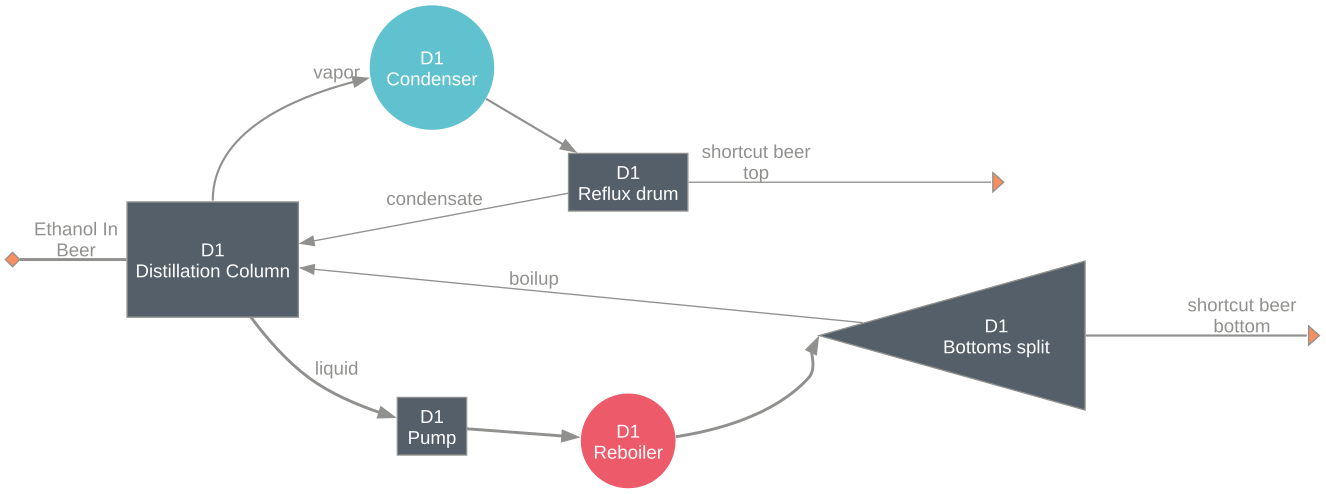

ShortcutColumn: D1
ins...
[0] Ethanol_In_Beer  
    phase: 'l', T: 388.15 K, P: 607950 Pa
    flow (kmol/hr): Water       2.17e+04
                    Ethanol     467
                    AceticAcid  61
                    LacticAcid  23.7
                    Xylose      2.1
                    Extract     67.8
                    Ash         4.11e+03
                    Lignin      86.3
                    Cellulose   21.6
                    Protein     115
                    Xylan       14.8
                    Cellulase   70
outs...
[0] shortcut_beer_top  
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kmol/hr): Water       2.01e+03
                    Ethanol     463
                    AceticAcid  12.1
                    LacticAcid  0.000479
[1] shortcut_beer_bottom  
    phase: 'l', T: 407.04 K, P: 303975 Pa
    flow (kmol/hr): Water       1.97e+04
                    Ethanol     4.06
                    AceticAcid  48.9
                    LacticAcid  23.7
               

In [10]:
beer_shortcut

In [11]:
beer_shortcut.results()

Distillation Column                                        Units        D1
Electricity         Power                                     kW        18
                    Cost                                  USD/hr      1.49
Cooling water       Duty                                   kJ/hr -7.88e+06
                    Flow                                 kmol/hr  5.38e+03
                    Cost                                  USD/hr      2.63
Low pressure steam  Duty                                   kJ/hr  1.44e+08
                    Flow                                 kmol/hr  3.73e+03
                    Cost                                  USD/hr       887
Design              Theoretical feed stage                               1
                    Theoretical stages                                   9
                    Minimum reflux                         Ratio      0.01
                    Reflux                                 Ratio      0.08
                    Actual stages                                       22
                    Height                                    ft      43.5
                    Diameter                                  ft      9.84
                    Wall thickness                            in     0.438
                    Weight                                    lb  2.85e+04
Purchase cost       Trays                                    USD  6.26e+04
                    Tower                                    USD  1.77e+05
                    Platform and ladders                     USD  4.43e+04
                    Condenser - Floating head                USD  3.64e+04
                    Reflux drum - Vertical pressure ...      USD  9.23e+04
                    Reflux drum - Platform and ladders       USD  1.75e+04
                    Pump - Pump                              USD     2e+04
                    Pump - Motor                             USD  1.63e+03
                    Reboiler - Floating head                 USD  5.38e+05
Total purchase cost                                          USD   9.9e+05
Utility cost                                              USD/hr       892

In [12]:
heater = bst.units.HXutility(ins=beer_shortcut-0, V=1, rigorous=True)
heater.simulate()

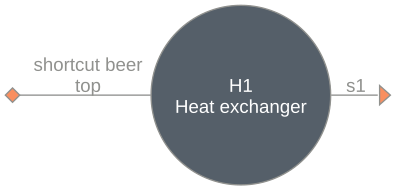

HXutility: H1
ins...
[0] shortcut_beer_top  from  ShortcutColumn-D1
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kmol/hr): Water       2.01e+03
                    Ethanol     463
                    AceticAcid  12.1
                    LacticAcid  0.000479
outs...
[0] s1  
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kmol/hr): Water       2.01e+03
                    Ethanol     463
                    AceticAcid  12.1
                    LacticAcid  0.000479


In [13]:
heater

In [14]:
rectification_shortcut = bst.units.ShortcutColumn(
    ins = heater-0,
    outs = ('shortcut_rectif_top','shortcut_rectif_bottom'),
    P = 3*101325,
    LHK=('Ethanol', 'Water'),
    y_top = 0.925/1.11,
    x_bot = 0.0005/2.55,
    k = 3,
    partial_condenser=True)
rectification_shortcut.simulate()

In [15]:
rectification_shortcut.show(flow ='kg/hr')

ShortcutColumn: D2
ins...
[0] s1  from  HXutility-H1
    phase: 'g', T: 400.82 K, P: 303975 Pa
    flow (kg/hr): Water       3.63e+04
                  Ethanol     2.13e+04
                  AceticAcid  728
                  LacticAcid  0.0432
outs...
[0] shortcut_rectif_top  
    phase: 'g', T: 382.22 K, P: 303975 Pa
    flow (kg/hr): Water       1.67e+03
                  Ethanol     2.13e+04
                  AceticAcid  0.422
[1] shortcut_rectif_bottom  
    phase: 'l', T: 406.96 K, P: 303975 Pa
    flow (kg/hr): Water       3.46e+04
                  Ethanol     17.4
                  AceticAcid  728
                  LacticAcid  0.0432


In [16]:
rectification_feed_stage = int(rectification_shortcut.design_results['Theoretical feed stage'])
rectification_feed_stage

1

In [17]:
rectification_shortcut.results()

Distillation Column                                        Units       D2
Electricity         Power                                     kW     7.37
                    Cost                                  USD/hr    0.609
Cooling water       Duty                                   kJ/hr -3.2e+08
                    Flow                                 kmol/hr 2.19e+05
                    Cost                                  USD/hr      107
Low pressure steam  Duty                                   kJ/hr 2.71e+08
                    Flow                                 kmol/hr    7e+03
                    Cost                                  USD/hr 1.66e+03
Design              Theoretical feed stage                              1
                    Theoretical stages                                 10
                    Minimum reflux                         Ratio     5.11
                    Reflux                                 Ratio     15.3
                    Actual stages                                      17
                    Height                                    ft     36.1
                    Diameter                                  ft       21
                    Wall thickness                            in    0.875
                    Weight                                    lb 1.25e+05
Purchase cost       Trays                                    USD 2.92e+05
                    Tower                                    USD  4.9e+05
                    Platform and ladders                     USD 6.16e+04
                    Condenser - Floating head                USD 4.25e+05
                    Reflux drum - Horizontal pressur...      USD 4.43e+04
                    Reflux drum - Platform and ladders       USD 5.14e+03
                    Pump - Pump                              USD 8.94e+03
                    Pump - Motor                             USD      913
                    Reboiler - Floating head                 USD 2.65e+06
Total purchase cost                                          USD 3.98e+06
Utility cost                                              USD/hr 1.77e+03

In [18]:
def _boilup_ratio(shortcut_column):
    outlet = shortcut_column.reboiler.outs[0]
    return outlet['g'].F_mol / outlet['l'].F_mol

In [19]:
boilup_beer = _boilup_ratio(beer_shortcut)
boilup_rectif = _boilup_ratio(rectification_shortcut)


In [20]:
N_stages_beer = int(beer_shortcut.design_results['Theoretical stages'])
feed_stage_beer = int(beer_shortcut.design_results['Theoretical feed stage'])
N_stages_rectif = max(int(rectification_shortcut.design_results['Theoretical stages']), 11)

In [21]:
int(beer_shortcut.design_results['Theoretical stages'])

9

In [22]:
# --- Column 1: beer/stripping MESH column. No condenser (reflux=0):
# the top vapor leaves the column fully vaporized and feeds column 2 directly.
beer_mesh = bst.MESHDistillation(
    'beer_mesh',
    ins=(ethanol_in_beer,),
    outs=('beer_mesh_vapor', 'beer_mesh_bottoms'),
    N_stages=N_stages_beer,
    feed_stages=[feed_stage_beer],
    reflux=0,
    boilup=boilup_beer,
    LHK=('Ethanol', 'Water'),
    P=3*101325,
)
beer_mesh.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\IPython\core\interactiveshell.py:3579: RuntimeWarning: undocked inlet Ethanol_In_Beer from D1; Ethanol_In_Beer is now docked at beer_mesh
  exec(code_obj, self.user_global_ns, self.user_ns)


In [23]:
beer_mesh.results()

Distillation                                    Units  beer_mesh
Electricity         Power                          kW       18.7
                    Cost                       USD/hr       1.55
Low pressure steam  Duty                        kJ/hr   9.74e+07
                    Flow                      kmol/hr   2.52e+03
                    Cost                       USD/hr        599
Design              Theoretical stages                         9
                    Actual stages                             13
                    Height                         ft       33.2
                    Diameter                       ft       10.1
                    Wall thickness                 in        0.5
                    Weight                         lb   2.67e+04
Purchase cost       Trays                         USD   5.11e+04
                    Tower                         USD    1.7e+05
                    Platform and ladders          USD   3.61e+04
                    Pump - Pump                   USD   2.05e+04
                    Pump - Motor                  USD   1.68e+03
                    Reboiler - Floating head      USD    5.3e+05
Total purchase cost                               USD    8.1e+05
Utility cost                                   USD/hr        601

In [24]:
reflux_recycle = bst.Stream('reflux_recycle', Ethanol=5331.9, Water=2043,
                             units='kg/hr', T=71+273.15, P=3*101325, phase='l')

In [25]:
rectif_mesh = bst.MESHDistillation(
    'rectif_mesh',
    ins=(beer_mesh-0, reflux_recycle),
    outs=('rectif_mesh_vapor', 'rectif_mesh_bottoms'),
    N_stages=N_stages_rectif,
    feed_stages=[10, 6],
    reflux=0,
    boilup=1,
    LHK=('Ethanol', 'Water'),
    P=3*101325,
    algorithm='sequential',
    method='fixed-point',

)
rectif_mesh.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: pump> no pump type available at current power (809 hp), head (1.66e+04 ft), kinematic viscosity (1.59e-05 m2/s), and NPSH (-1.48e+04 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '


In [26]:
boilup_rectif

3.39535574441068

In [27]:
# --- Heat recovery: condense the rectifier's vapor product against process
# water (33 C -> 100 C), sized by direct energy balance each pass.
sieve_water_in = bst.Stream('sieve_water_in', Water=10, units='kmol/hr',
                             T=33+273.15, P=101325, phase='l')


In [28]:
HX_sieve = bst.HXprocess(
    'HX_sieve',
    ins=(rectif_mesh-0, sieve_water_in),
    outs=('rectif_vapor_cooled', 'sieve_water_heated'),
)

HX_sieve.simulate()

In [29]:
@HX_sieve.add_specification(run=True)
def set_sieve_water_flow():
    vapor_in = HX_sieve.ins[0]
    liquid_ref = vapor_in.copy()
    liquid_ref.phase = 'l'
    Q = vapor_in.H - liquid_ref.H  # duty released condensing vapor to liquid at column P
    water_ref_in = bst.Stream(None, Water=1, units='kmol/hr', T=33+273.15,
                               P=101325, phase='l', thermo=chems)
    water_ref_out = water_ref_in.copy()
    water_ref_out.T = 100+273.15
    dH_per_kmol = water_ref_out.H - water_ref_in.H
    HX_sieve.ins[1].imol['Water'] = Q / dH_per_kmol

# --- Molecular sieve, modeled as a component splitter: rejects all water
# and ~25% of the ethanol (matches a target reject of 5331.9 kg/hr ethanol,
# based on the converged shortcut's overhead flow). AceticAcid/LacticAcid
# are not water-selective, so they're routed entirely to product -- leaving
# them unspecified defaults them to the reject side and causes runaway
# accumulation in the recycle loop.
sieve_ethanol_reject_frac = 5331.9 / rectification_shortcut.outs[0].imass['Ethanol']

molecular_sieve = bst.Splitter(
    'molecular_sieve',
    ins=HX_sieve-0,
    outs=('sieve_product', 'sieve_reject'),
    split=dict(Ethanol=1-sieve_ethanol_reject_frac, Water=0.0,
               AceticAcid=1.0, LacticAcid=1.0),
)

# --- Makeup water tops the sieve reject up to the target reflux composition
# (5331.9 kg/hr ethanol, 2043 kg/hr water) before returning to the column.
# No pump: makeup water is assumed available at 3 atm already.
makeup_water_flow = 2043 - rectification_shortcut.outs[0].imass['Water']
makeup_water = bst.Stream('makeup_water', Water=makeup_water_flow, units='kg/hr',
                           T=25+273.15, P=3*101325, phase='l')

reflux_mixer = bst.Mixer('reflux_mixer', ins=(molecular_sieve-1, makeup_water),
                          outs='reflux_mixed')

# Final cooler brings the combined reject + makeup water back to 71 C before
# re-entering the column; no pump/compressor -- pressure carries through at 3 atm.
cooler_reflux = bst.HXutility('cooler_reflux', ins=reflux_mixer-0,
                               outs=reflux_recycle, T=71+273.15,
                               rigorous=True)

rectif_loop_sys = bst.System(
    'rectif_loop_sys',
    path=(beer_mesh, rectif_mesh, HX_sieve, molecular_sieve, reflux_mixer, cooler_reflux),
    recycle=reflux_recycle,
)
rectif_loop_sys.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\vle.py:71: RuntimeWarning: overflow encountered in exp
  Ks = np.exp(xVlogK[n+1:])
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: pump> no pump type available at current power (810 hp), head (1.22e+04 ft), kinematic viscosity (2.77e-05 m2/s), and NPSH (-9.39e+03 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '


In [30]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

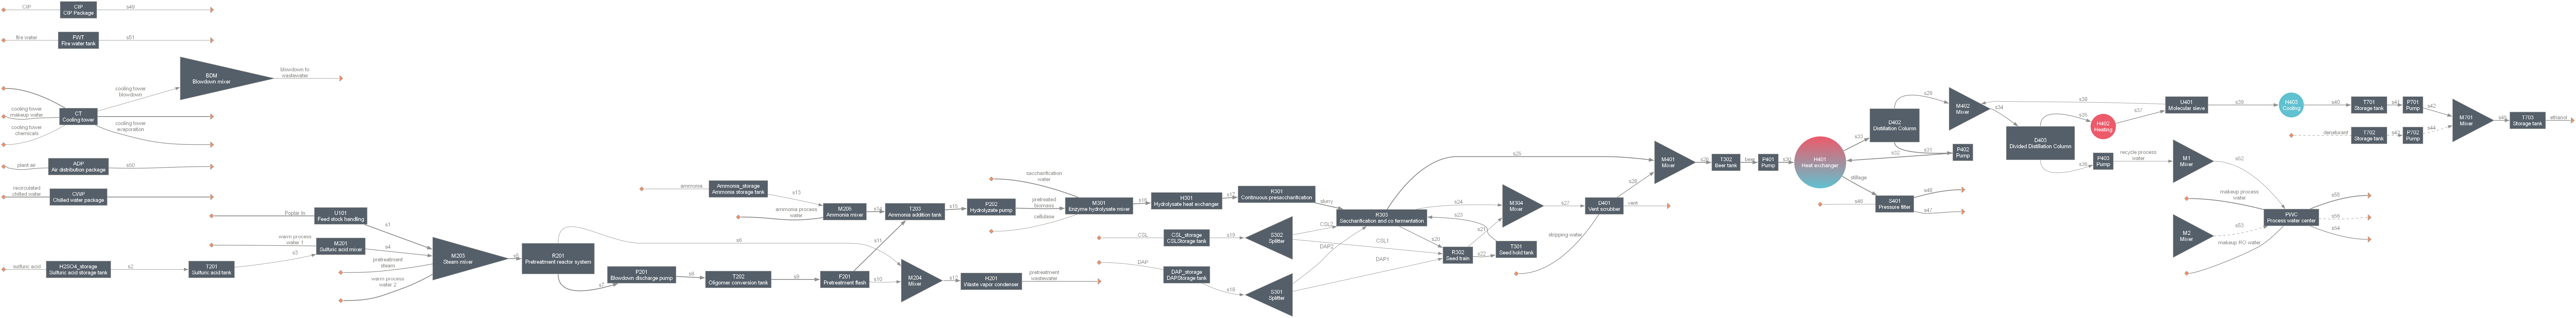

In [ ]:
etoh_system.diagram(format = 'png')

In [ ]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [ ]:
F.D402.show(flow = 'kg/hr', composition=True)

BinaryDistillation: D402
ins...
[0] s33  from  HXprocess-H401
    phase: 'l', T: 379.99 K, P: 607950 Pa
    composition (%): Water              88.5
                     Ethanol            3.83
                     AceticAcid         0.395
                     Furfural           0.0351
                     Glycerol           0.0313
                     NH3                0.000459
                     LacticAcid         0.3
                     SuccinicAcid       0.0711
                     DAP                0.0355
                     AmmoniumSulfate    0.399
                     HMF                0.0215
                     Glucose            0.112
                     Xylose             0.121
                     Arabinose          0.0272
                     Extract            0.22
                     Ash                0.165
                     Lignin             3.71
                     SolubleLignin      0.196
                     GlucoseOligomer    0.247
                   

In [ ]:
bst.units.BinaryDistillation

In [ ]:
from atj_saf.atj_bst.etj_chemicals import create_chemicals
chems = create_chemicals()
bst.settings.set_thermo(chems)


In [ ]:
feed = bst.Stream('feed',
              Ethanol=109271.1*0.2367,
              Water=109271.1*(1-0.2367),
              units='kg/hr',
              phase = 'g',
              T=132.1+273.15,
              P = 3*101325)

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: feed> has been replaced in registry
  self._register(ID)


In [ ]:
bst.units.MESHDistillation

In [ ]:
feed

Stream: feed
phase: 'g', T: 405.25 K, P: 303975 Pa
flow (kmol/hr): Water    4.63e+03
                Ethanol  561
